这里说频率是指一个机场航班出现的频率

## 加载数据

数据已经预处理过了

In [1]:
import pandas as pd


# 加载数据
pd.set_option('display.max_columns', None)  # 显示所有列

data = pd.read_csv('../my/hh_result/result_202406_pax>0.csv', dtype={'aircraft': str})

# 查看前几行数据，确保加载成功
print(data.head())

print(data.info())

  flt_no    a    b    c bd_type    cap aircraft  legs  leg_no  duration  pax  \
0   3455  URC  GYS  NNG      窄体  180.0      320     3       1      2.68   49   
1   3432  SHE  XIY  XIC      窄体  164.0      320     3       1      3.05  152   
2   3439  XIC  MIG  NKG      窄体    NaN      320     3       3       NaN   64   
3   3421  CSX  CKG  NaN      窄体  189.0      321     1       1      1.20  187   
4   3446  SYX  ZHA  CGO      窄体  172.0      738     3       1      0.93   64   

   year  month  day  weekday  hour  minute  second from   to   unit_price  
0  2024      6   20        3     7      40       0  URC  GYS  1143.265306  
1  2024      6   14        4    14      10       0  SHE  XIY   746.223684  
2  2024      6   14        4    12      40       0  XIC  NKG   758.859375  
3  2024      6   12        2     8      25       0  CSX  CKG   481.978610  
4  2024      6   12        2    18      20       0  SYX  ZHA   495.578125  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352984 entrie

In [2]:
# 随机抽取5万条数据
data = data.sample(n=20000, random_state=42)

# 查看抽样后的数据信息
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 332557 to 105215
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   flt_no      20000 non-null  object 
 1   a           20000 non-null  object 
 2   b           20000 non-null  object 
 3   c           7481 non-null   object 
 4   bd_type     20000 non-null  object 
 5   cap         17481 non-null  float64
 6   aircraft    20000 non-null  object 
 7   legs        20000 non-null  int64  
 8   leg_no      20000 non-null  int64  
 9   duration    17481 non-null  float64
 10  pax         20000 non-null  int64  
 11  year        20000 non-null  int64  
 12  month       20000 non-null  int64  
 13  day         20000 non-null  int64  
 14  weekday     20000 non-null  int64  
 15  hour        20000 non-null  int64  
 16  minute      20000 non-null  int64  
 17  second      20000 non-null  int64  
 18  from        20000 non-null  object 
 19  to          20000 non-nu

In [3]:
# 检查标准化后的统计信息
print("\n标准化后的统计信息：")
print(data['pax'].describe())


标准化后的统计信息：
count    20000.000000
mean       117.416850
std         53.789529
min          1.000000
25%         82.000000
50%        123.000000
75%        152.000000
max        385.000000
Name: pax, dtype: float64


## 编码分类变量

### 新增城市标签

In [4]:
import json
# 加载字典
with open('../my/encoder/city_labels_航班频率加权图标签.json', 'r') as file:
    city_labels_loaded = json.load(file)

print("加载的字典：", city_labels_loaded)

加载的字典： {'AAT': 2, 'AKU': 2, 'BPL': 2, 'CAN': 1, 'CGO': 1, 'CGQ': 1, 'CKG': 1, 'CSX': 1, 'KCA': 2, 'KHG': 2, 'KJI': 2, 'KRL': 2, 'KRY': 2, 'PKX': 1, 'PVG': 1, 'SHF': 2, 'SZX': 1, 'TCG': 2, 'TFU': 1, 'TLQ': 2, 'URC': 2, 'XIY': 1, 'YIN': 2, 'ACF': 2, 'HGH': 1, 'HTN': 2, 'RQA': 2, 'TWC': 2, 'YTW': 2, 'ACX': 1, 'BAV': 0, 'BFJ': 1, 'BZX': 1, 'CTU': 1, 'FOC': 1, 'FUO': 1, 'HAK': 1, 'HUZ': 1, 'JHG': 1, 'JUZ': 1, 'KHN': 1, 'KJH': 1, 'KMG': 1, 'KWE': 1, 'LLB': 1, 'NGB': 1, 'NKG': 1, 'NNG': 1, 'SHS': 1, 'SWA': 1, 'TEN': 1, 'WHA': 1, 'WMT': 1, 'WNZ': 1, 'WUH': 1, 'ZUH': 1, 'ZYI': 1, 'AEB': 1, 'AHJ': 1, 'LXA': 1, 'AKA': 1, 'JJN': 1, 'TSN': 1, 'FYN': 2, 'HMI': 2, 'HXD': 1, 'INC': 1, 'LHW': 1, 'PEK': 1, 'QSZ': 2, 'TAO': 1, 'XNN': 1, 'ZFL': 2, 'AOG': 1, 'AQG': 1, 'AVA': 1, 'LJG': 1, 'AXF': 0, 'HET': 0, 'BAR': 1, 'DSN': 1, 'HFE': 1, 'JGS': 1, 'JMJ': 1, 'SHA': 1, 'SHE': 1, 'SJW': 1, 'TYN': 1, 'YBP': 1, 'CIF': 0, 'DLC': 1, 'ERL': 0, 'HDG': 1, 'HLH': 0, 'HRB': 1, 'LFQ': 1, 'NZH': 0, 'TGO': 0, 'TNA': 1, 'W

In [5]:
# 使用 map 对 'a', 'b', 'c', 'from', 'to' 列进行标签化，新增对应的标签列
data['a_label'] = data['a'].map(city_labels_loaded)
data['b_label'] = data['b'].map(city_labels_loaded)
data['c_label'] = data['c'].map(city_labels_loaded)
data['from_label'] = data['from'].map(city_labels_loaded)
data['to_label'] = data['to'].map(city_labels_loaded)

### 新增城市二维嵌入

In [6]:
import json

# 加载字典
with open('../my/encoder/城市嵌入编码_航班频率加权图.json', 'r') as file:
    city_embeddings = json.load(file)

print("加载的字典：", city_embeddings)


加载的字典： {'AAT': [2.2845218181610107, 0.33310964703559875], 'AKU': [2.230104923248291, 0.014805909246206284], 'BPL': [2.2067112922668457, -0.06403908878564835], 'CAN': [-0.4215731918811798, -0.5733268857002258], 'CGO': [0.15557636320590973, 0.0020464863628149033], 'CGQ': [-0.5135295391082764, -0.017136098816990852], 'CKG': [-0.23730406165122986, -0.2910309135913849], 'CSX': [-0.10720260441303253, -0.1790555864572525], 'KCA': [2.6338319778442383, 0.19144530594348907], 'KHG': [2.0393192768096924, 0.113322913646698], 'KJI': [2.3451597690582275, 0.37647759914398193], 'KRL': [2.3045637607574463, 0.5154383182525635], 'KRY': [2.056691884994507, 0.21619947254657745], 'PKX': [-0.5798766613006592, 0.11405231803655624], 'PVG': [-0.755786657333374, -0.07646799832582474], 'SHF': [2.3801584243774414, -0.12228715419769287], 'SZX': [-0.5356070399284363, -0.43963876366615295], 'TCG': [1.9911434650421143, 0.1193806454539299], 'TFU': [0.1950410157442093, -0.596275806427002], 'TLQ': [2.8264999389648438, 0.1

In [7]:
import pandas as pd
import numpy as np

# 将 city_embeddings 转换为 DataFrame
embedding_df = pd.DataFrame.from_dict(city_embeddings, orient='index', columns=['embedding_1', 'embedding_2'])
embedding_df.index.name = 'city'

# 用 'a', 'b', 'c', 'from', 'to' 字段与 embedding_df 合并
data = data.merge(embedding_df, left_on='a', right_index=True, how='left')
data.rename(columns={'embedding_1': 'a_embedding_1', 'embedding_2': 'a_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='b', right_index=True, how='left')
data.rename(columns={'embedding_1': 'b_embedding_1', 'embedding_2': 'b_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='c', right_index=True, how='left')
data.rename(columns={'embedding_1': 'c_embedding_1', 'embedding_2': 'c_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='from', right_index=True, how='left')
data.rename(columns={'embedding_1': 'from_embedding_1', 'embedding_2': 'from_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='to', right_index=True, how='left')
data.rename(columns={'embedding_1': 'to_embedding_1', 'embedding_2': 'to_embedding_2'}, inplace=True)

# 查看添加的新列
print(data[['a_embedding_1', 'a_embedding_2', 'b_embedding_1', 'b_embedding_2', 'c_embedding_1', 'c_embedding_2', 'from_embedding_1', 'from_embedding_2', 'to_embedding_1', 'to_embedding_2']])

        a_embedding_1  a_embedding_2  b_embedding_1  b_embedding_2  \
332557       0.466810      -0.894450       0.350280      -0.231762   
289030      -0.203958      -0.214063       0.195041      -0.596276   
303579       1.273160       0.122845       0.388170      -0.209202   
334870      -0.665647      -0.814677      -0.319591      -0.266214   
301669      -0.944952      -0.523688      -0.635527      -0.437360   
...               ...            ...            ...            ...   
248195      -0.940053       0.484287      -0.755787      -0.076468   
179040      -0.724062      -0.097747      -0.910092       0.481879   
31647       -0.319591      -0.266214      -0.535607      -0.439639   
231647      -0.236141      -0.140572      -0.614349      -0.146468   
105215       0.184190       0.146134      -0.121681      -0.134001   

        c_embedding_1  c_embedding_2  from_embedding_1  from_embedding_2  \
332557            NaN            NaN          0.466810         -0.894450   
289030 

### 统计不同城市的频率

### 对'a', 'b', 'c', 'from', 'to'进行频率编码

In [8]:
# 加载city_map
with open('../my/encoder/city_map_频率编码.json', 'r') as f:
    city_map = json.load(f)

# 使用 city_map 替换指定列的值
columns_to_replace = ['a', 'b', 'c', 'from', 'to']

# 遍历指定列并直接用 map 映射
for col in columns_to_replace:
    data[col] = data[col].map(city_map)


print(data)

       flt_no       a       b         c bd_type    cap aircraft  legs  leg_no  \
332557   2148   71771  357460       NaN      窄体  122.0      319     1       1   
289030   8331  361905  458602       NaN      窄体  128.0      319     1       1   
303579   6798  230094  142121  143575.0      窄体  172.0      738     3       2   
334870   8972   77111  262691  217577.0      窄体    NaN      320     3       3   
301669   8527  132157  196066       NaN      窄体  185.0      321     1       1   
...       ...     ...     ...       ...     ...    ...      ...   ...     ...   
248195   9062  255010  410930       NaN      窄体  170.0      738     1       1   
179040   2843  199299   72574  101486.0      窄体  158.0      320     3       1   
31647    9848  262691  484319       NaN      窄体  162.0      737     1       1   
231647   2409  349069  140652  131379.0      窄体  176.0      737     3       1   
105215   1392    1626  400617       NaN      窄体  167.0      737     1       1   

        duration  pax  year

### 对'flt_no', 'bd_type', 'aircraft'进行标签编码

In [9]:
data.head(5)

,flt_no,a,b,c,bd_type,cap,aircraft,legs,leg_no,duration,pax,year,month,day,weekday,hour,minute,second,from,to,unit_price,a_label,b_label,c_label,from_label,to_label,a_embedding_1,a_embedding_2,b_embedding_1,b_embedding_2,c_embedding_1,c_embedding_2,from_embedding_1,from_embedding_2,to_embedding_1,to_embedding_2
332557,2148,71771,357460,NaN,窄体,122.0,319,1,1,2.65,86,2024,6,29,5,14,25,0,71771,357460,1275.162791,1,1,NaN,1,1,0.466810,-0.894450,0.350280,-0.231762,NaN,NaN,0.466810,-0.894450,0.350280,-0.231762
289030,8331,361905,458602,NaN,窄体,128.0,319,1,1,2.40,125,2024,6,27,3,17,20,0,361905,458602,1262.152000,1,1,NaN,1,1,-0.203958,-0.214063,0.195041,-0.596276,NaN,NaN,-0.203958,-0.214063,0.195041,-0.596276
303579,6798,230094,142121,143575.0,窄体,172.0,738,3,2,2.23,55,2024,6,15,5,19,0,0,142121,143575,770.563636,2,1,1.0,1,1,1.273160,0.122845,0.388170,-0.209202,-0.368271,-0.366432,0.388170,-0.209202,-0.368271,-0.366432
334870,8972,77111,262691,217577.0,窄体,NaN,320,3,3,NaN,11,2024,6,26,2,13,35,0,77111,217577,895.090909,1,1,1.0,1,1,-0.665647,-0.814677,-0.319591,-0.266214,-0.513530,-0.017136,-0.665647,-0.814677,-0.513530,-0.017136
301669,8527,132157,196066,NaN,窄体,185.0,321,1,1,2.18,180,2024,6,30,6,16,10,0,132157,196066,738.088889,1,1,NaN,1,1,-0.944952,-0.523688,-0.635527,-0.437360,NaN,NaN,-0.944952,-0.523688,-0.635527,-0.437360


In [10]:
import joblib
from sklearn.preprocessing import LabelEncoder
import os

# 定义需要编码的分类特征
categorical_columns = ['flt_no', 'bd_type', 'aircraft']

# 从保存的文件中加载编码器并应用到data
for col in categorical_columns:
    # 加载编码器
    encoder_path = os.path.join('../my/encoder/', f"{col}_encoder_all.pkl")
    le = joblib.load(encoder_path)
    
    try:
        # 对data进行转换
        data[col] = le.transform(data[col])
        print(f"{col}列编码完成")
    except ValueError as e:
        # 如果遇到新的类别，打印错误信息
        print(f"{col}列编码出错: {str(e)}")
        # 找出新的类别
        new_categories = set(data[col]) - set(le.classes_)
        print(f"{col}列中的新类别: {new_categories}")

# 查看编码后的结果
print("\n编码后的前几行数据：")
print(data[categorical_columns].head())

flt_no列编码完成
bd_type列编码完成
aircraft列编码完成

编码后的前几行数据：
        flt_no  bd_type  aircraft
332557    1381        3         1
289030    9112        3         1
303579    7731        3        27
334870   10091        3         6
301669    9388        3         7


## 特征和目标分离
我们要预测的是pax字段，其他字段作为特征。

In [11]:
# 特征列
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft',  'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','holiday', 'hour', 'minute', 'second', 'from', 'to','unit_price']]
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price']]
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label']]

# 有abc，有标签，有嵌入
X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label','a_embedding_1' , 'a_embedding_2' , 'b_embedding_1','b_embedding_2' , 'c_embedding_1' , 'c_embedding_2' , 'from_embedding_1','from_embedding_2' , 'to_embedding_1' , 'to_embedding_2']]

# 删除了abc，但有标签，有嵌入
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label','a_embedding_1' , 'a_embedding_2' , 'b_embedding_1','b_embedding_2' , 'c_embedding_1' , 'c_embedding_2' , 'from_embedding_1','from_embedding_2' , 'to_embedding_1' , 'to_embedding_2']]

# 目标列
y = data['pax']

In [12]:
test_x = X.head(1)
test_x

,flt_no,bd_type,cap,aircraft,legs,leg_no,duration,a,b,c,year,month,day,weekday,hour,minute,second,from,to,unit_price,a_label,b_label,c_label,from_label,to_label,a_embedding_1,a_embedding_2,b_embedding_1,b_embedding_2,c_embedding_1,c_embedding_2,from_embedding_1,from_embedding_2,to_embedding_1,to_embedding_2
332557,1381,3,122.0,1,1,1,2.65,71771,357460,NaN,2024,6,29,5,14,25,0,71771,357460,1275.162791,1,1,NaN,1,1,0.46681,-0.89445,0.35028,-0.231762,NaN,NaN,0.46681,-0.89445,0.35028,-0.231762


In [13]:
y.head(5)

332557     86
289030    125
303579     55
334870     11
301669    180
Name: pax, dtype: int64

### 对x进行标准化

In [14]:
from sklearn.preprocessing import StandardScaler
import joblib

# 定义需要标准化的特征列（与训练时相同的特征）
features = ['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 
           'a', 'b', 'c', 'year', 'month', 'day', 'weekday', 'hour', 'minute', 'second', 
           'from', 'to', 'unit_price', 'a_label', 'b_label', 'c_label', 'from_label', 'to_label',
           'a_embedding_1', 'a_embedding_2', 'b_embedding_1', 'b_embedding_2', 
           'c_embedding_1', 'c_embedding_2', 'from_embedding_1', 'from_embedding_2', 
           'to_embedding_1', 'to_embedding_2']

# 加载保存的标准化器
scaler = joblib.load('../my/encoder/standard_scaler_x.pkl')

# 对数据进行标准化
data_scaled = scaler.transform(data[features])

# 将标准化后的数据转回DataFrame格式
data_scaled = pd.DataFrame(data_scaled, columns=features, index=data.index)

# 将标准化后的数据替换回原始数据框中
for col in features:
    data[col] = data_scaled[col]

# 查看标准化后的结果
print("标准化后的数据预览（前1行）：")
pd.set_option('display.max_columns', None)  # 显示所有列
print(data[features].head(1))

# 检查标准化后的统计信息
print("\n标准化后的统计信息：")
print(data[features].describe())

标准化后的数据预览（前1行）：
          flt_no   bd_type       cap  aircraft      legs    leg_no  duration  \
332557 -1.361251  0.328077 -1.264178 -1.328391 -0.795477 -0.548858  0.825993   

               a         b   c     year    month       day   weekday  \
332557 -1.194048  0.826231 NaN  1.53824  0.14264  1.496521  0.994575   

            hour    minute  second      from       to  unit_price   a_label  \
332557  0.083744 -0.073878     0.0 -1.112794  0.70429     1.21655 -0.074104   

         b_label  c_label  from_label  to_label  a_embedding_1  a_embedding_2  \
332557 -0.034321      NaN   -0.061516 -0.061306        1.28252      -1.702536   

        b_embedding_1  b_embedding_2  c_embedding_1  c_embedding_2  \
332557        1.14685      -0.286114            NaN            NaN   

        from_embedding_1  from_embedding_2  to_embedding_1  to_embedding_2  
332557          1.312702           -1.7253        1.092847        -0.27684  

标准化后的统计信息：
             flt_no       bd_type           cap  

### 对y进行标准化

In [15]:
# 加载y的标准化器
scaler_y = joblib.load('../my/encoder/standard_scaler_y.pkl')

# 对目标变量进行标准化
y = data['pax']  # 假设目标列名为'pax'
# y_scaled = scaler_y.transform(y.values.reshape(-1, 1))  # 将y转换为2D数组进行标准化

# # 将标准化后的数据转回DataFrame格式
# y_scaled = pd.DataFrame(y_scaled, columns=['pax_scaled'], index=data.index)

# # 将标准化后的值添加到原始数据框中
# data['pax'] = y_scaled['pax_scaled']

## XGBoost模型预测

In [16]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 加载模型
model = xgb.Booster()
model.load_model("../my/model/频率编码/归一化_xgboost_model_1000.json")

# 转换为DMatrix格式
dmatrix = xgb.DMatrix(data_scaled)

# 进行预测
scaled_predictions = model.predict(dmatrix)

# 将标准化的预测值转换回原始尺度
predictions = scaler_y.inverse_transform(scaled_predictions.reshape(-1, 1))

In [17]:
predictions

array([[108.771866],
       [118.638374],
       [ 97.77042 ],
       ...,
       [114.72231 ],
       [124.77595 ],
       [106.33963 ]], dtype=float32)

In [18]:
# 正确的写法
test_results = list(zip(predictions[:100], y[:100]))  # 真实值和预测值

print("\n20条测试结果（真实值 vs 预测值）:")
for i, (true_value, pred_value) in enumerate(test_results[:40]):
    # 如果是多维数组，使用 .item() 转换为标量
    true_value = true_value.item() if isinstance(true_value, np.ndarray) else true_value
    pred_value = pred_value.item() if isinstance(pred_value, np.ndarray) else pred_value
    print(f"第{i+1}条: 真实值={true_value}, 预测值={pred_value:.2f}")



20条测试结果（真实值 vs 预测值）:
第1条: 真实值=108.77186584472656, 预测值=86.00
第2条: 真实值=118.63837432861328, 预测值=125.00
第3条: 真实值=97.77041625976562, 预测值=55.00
第4条: 真实值=36.496131896972656, 预测值=11.00
第5条: 真实值=168.55093383789062, 预测值=180.00
第6条: 真实值=108.68565368652344, 预测值=115.00
第7条: 真实值=135.1201934814453, 预测值=149.00
第8条: 真实值=35.22412872314453, 预测值=75.00
第9条: 真实值=108.09373474121094, 预测值=137.00
第10条: 真实值=132.07037353515625, 预测值=108.00
第11条: 真实值=138.34957885742188, 预测值=139.00
第12条: 真实值=87.2619857788086, 预测值=77.00
第13条: 真实值=150.50755310058594, 预测值=162.00
第14条: 真实值=137.4976806640625, 预测值=174.00
第15条: 真实值=173.93621826171875, 预测值=167.00
第16条: 真实值=32.19792175292969, 预测值=17.00
第17条: 真实值=36.98809051513672, 预测值=15.00
第18条: 真实值=70.31169128417969, 预测值=36.00
第19条: 真实值=70.53912353515625, 预测值=86.00
第20条: 真实值=154.00816345214844, 预测值=161.00
第21条: 真实值=154.31492614746094, 预测值=163.00
第22条: 真实值=30.589012145996094, 预测值=33.00
第23条: 真实值=104.42631530761719, 预测值=88.00
第24条: 真实值=18.45526123046875, 预测值=26.00
第25条: 真实值=131.645904541015

## 测试指标

In [19]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_smape(y_true, y_pred):
    """
    计算 Symmetric Mean Absolute Percentage Error (SMAPE)
    """
    y_true, y_pred = np.array(y_true).ravel(), np.array(y_pred).ravel()
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_pred - y_true)
    
    # 避免除以零，将分母中为零的项替换为一个小值
    denominator = np.where(denominator == 0, 1e-8, denominator)
    
    smape = 100 * np.mean(diff / denominator)
    return smape


def calculate_mape(y_true, y_pred):
    """
    计算 Mean Absolute Percentage Error (MAPE)
    """
    y_true, y_pred = np.array(y_true).ravel(), np.array(y_pred).ravel()
    
    # 避免除以零，将 y_true 中的零值替换为一个小值
    y_true = np.where(y_true == 0, 1e-8, y_true)
    
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    return mape


# 假设 y_test 和 y_pred 已经是标准化反归一化后的数据
# 将其转换为一维数组以确保形状一致
y_test = np.array(y).ravel()
y_pred = np.array(predictions).ravel()

# 评估指标
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = calculate_mape(y_test, y_pred)
smape = calculate_smape(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 打印结果
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')
print(f'Symmetric Mean Absolute Percentage Error (SMAPE): {smape:.4f}%')
print(f'R-squared (R²): {r2:.4f}')


Mean Squared Error (MSE): 566.2317
Root Mean Squared Error (RMSE): 23.7956
Mean Absolute Error (MAE): 18.0426
Mean Absolute Percentage Error (MAPE): 33.5922%
Symmetric Mean Absolute Percentage Error (SMAPE): 20.9520%
R-squared (R²): 0.8043


似乎对于较小值预测存在误差

In [20]:
def calculate_smape(y_true, y_pred):
    """
    计算 Symmetric Mean Absolute Percentage Error (SMAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    return smape

def calculate_mape(y_true, y_pred):
    """
    计算 Mean Absolute Percentage Error (MAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    return mape

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 评估模型
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = calculate_mape(y_test, y_pred)
smape = calculate_smape(y_test, y_pred)

# 打印结果
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')
print(f'Symmetric Mean Absolute Percentage Error (SMAPE): {smape:.4f}%')

Mean Squared Error (MSE): 566.2317
Root Mean Squared Error (RMSE): 23.7956
Mean Absolute Error (MAE): 18.0426
Mean Absolute Percentage Error (MAPE): 33.5922%
Symmetric Mean Absolute Percentage Error (SMAPE): 20.9520%


## 保存模型

## 超参数设置

## 不同特征重要程度测试

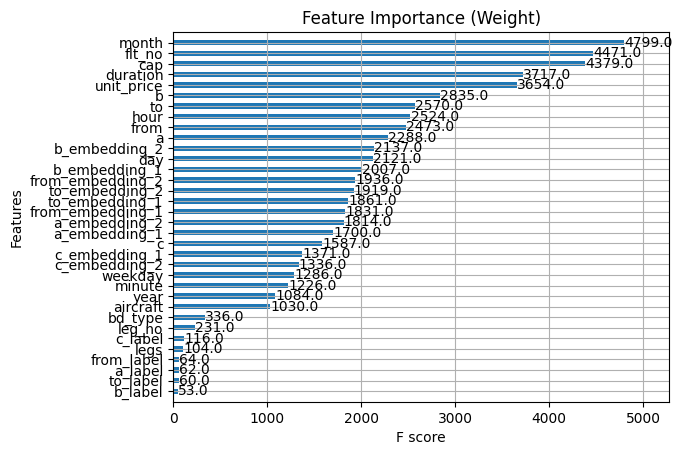

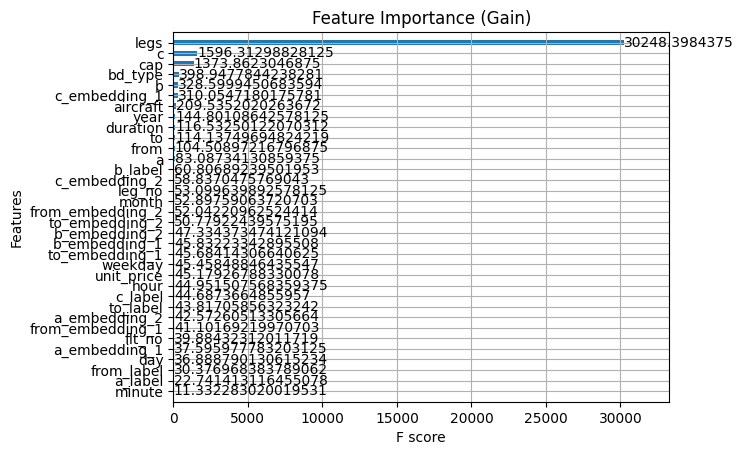

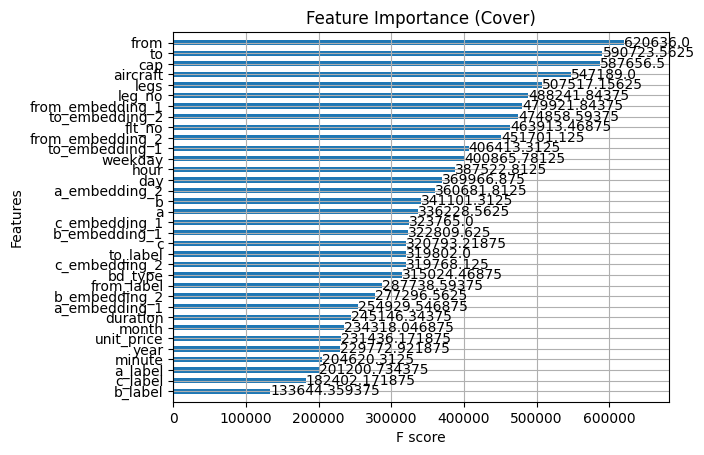

In [22]:
import xgboost as xgb
import matplotlib.pyplot as plt

# 假设 model 是训练好的 XGBoost 模型
xgb.plot_importance(model, importance_type='weight', title="Feature Importance (Weight)", height=0.5)
plt.show()

xgb.plot_importance(model, importance_type='gain', title="Feature Importance (Gain)", height=0.5)
plt.show()

xgb.plot_importance(model, importance_type='cover', title="Feature Importance (Cover)", height=0.5)
plt.show()